Title: SEM_calibration_split.ipynb

Purpose: Optimize the SEM for the ERA5 data in Germany

Author: Onno Nennecke on 27.01.2026 Modified: 12.02.2026

Input data: 

- Preprocessed ERA5 Data 
    - This file lies here: '/climca/people/onennecke/not_debiased_data/'
- Installed capacity grids: wind_offshore_ic_{year}.nc, wind_onshore_ic_{year}.nc, solar_ic_netto_{year}.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/
- Wind hub height grids: wind_offshore_height_weighted_{year}.nc, wind_onshore_height_weighted_{year}.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/ 
- Regridded population data: population_regrid_weights.nc
    - This file lies here: /climca/people/onennecke/population_data/
- Fit values from vdW Paper: demand_fit_values_week.nc
    - This file lies here: /climca/people/onennecke/population_data/

Output data:

- Timeseries of production, demand and RL
    - This file lies here: f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries.nc'
    - Bias corrected (Not used): (This file lies here: f'/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/{ESM}_{run}_timeseries.nc')

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
import gc

from sklearn.metrics import root_mean_squared_error
from scipy.optimize import minimize

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load datasets

In [2]:
years = range(2015, 2025)

grid_offshore = {}
grid_onshore = {}
grid_offshore_hh = {}
grid_onshore_hh = {}
grid_solar = {}

for year in years:
    grid_offshore_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_{year}.nc')
    grid_offshore[year] = grid_offshore_temp['wind_off_cap']
    grid_onshore_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic_{year}.nc')
    grid_onshore[year] = grid_onshore_temp['wind_on_cap']
    grid_solar_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto_{year}.nc')
    grid_solar[year] = grid_solar_temp['solar_cap']
    grid_offshore_hh_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted_{year}.nc')
    grid_offshore_hh[year] = grid_offshore_hh_temp['wind_off_hub_height']
    grid_onshore_hh_temp = xr.open_dataset(f'/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted_{year}.nc')
    grid_onshore_hh[year] = grid_onshore_hh_temp['wind_on_hub_height']



In [3]:
mask_offshore = xr.where(np.isfinite(grid_offshore[2024]), 1, 0)
mask_onshore = xr.where(np.isfinite(grid_onshore[2024]), 1, 0)
mask_solar = xr.where(np.isfinite(grid_solar[2024]), 1, 0)

In [4]:
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [5]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

In [6]:
# Load SMARD data for comparison
SMARD_data_prod = pd.read_csv('/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')
date = pd.to_datetime(SMARD_data_prod['Datum von'].astype(str).str.zfill(8), format='%d%m%Y')
wind_off_prod = SMARD_data_prod['Wind Offshore [MWh] Berechnete Auflösungen']
wind_on_prod = SMARD_data_prod['Wind Onshore [MWh] Berechnete Auflösungen']
solar_prod = SMARD_data_prod['Photovoltaik [MWh] Berechnete Auflösungen']
total_prod = wind_off_prod + wind_on_prod + solar_prod

df = pd.DataFrame({
    'date': date,
    'wind_offshore_SMARD': wind_off_prod / 1000,  # Convert to GWh
    'wind_onshore_SMARD': wind_on_prod / 1000,  # Convert to GWh
    'solar_SMARD': solar_prod / 1000,  # Convert to GWh
    'total_production_SMARD': total_prod / 1000,  # Convert to GWh'
    'wind_offshore_model': np.nan,
    'wind_onshore_model': np.nan,
    'solar_model': np.nan,
    'total_production_model': np.nan
})
# Cut data to the same time period as ERA5 data (2015-2024)
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2024-12-31')]
# Remove leap days
df = df[~((df['date'].dt.month == 2) & (df['date'].dt.day == 29))]
df


,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,total_production_SMARD,wind_offshore_model,wind_onshore_model,solar_model,total_production_model
0,2015-01-01,12.50850,298.79175,17.08025,328.38050,NaN,NaN,NaN,NaN
1,2015-01-02,10.32925,591.62075,7.75900,609.70900,NaN,NaN,NaN,NaN
2,2015-01-03,12.11950,457.04350,7.23475,476.39775,NaN,NaN,NaN,NaN
3,2015-01-04,11.53850,379.02950,19.98250,410.55050,NaN,NaN,NaN,NaN
4,2015-01-05,7.74550,219.62350,26.52225,253.89125,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3648,2024-12-27,2.94125,46.42200,61.20575,110.56900,NaN,NaN,NaN,NaN
3649,2024-12-28,22.34775,31.44225,61.08850,114.87850,NaN,NaN,NaN,NaN
3650,2024-12-29,97.29825,257.39450,39.71900,394.41175,NaN,NaN,NaN,NaN
3651,2024-12-30,61.18675,534.34725,22.92750,618.46150,NaN,NaN,NaN,NaN


### Define used models

In [7]:
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = era5_row
used_runs['Ref'] = 1

used_runs

,ESM,Institution,run,Ref
0,ERA5,ECMWF,hist,1


### Run SEM

In [8]:
run_time = time.time()
ESM = used_runs['ESM'][0]
Inst = used_runs['Institution'][0]
run = used_runs['run'][0]
# print(f'Processing Run Nr. {0+1}, {ESM}, {Inst}, {run}, \n')
# base_path = '/climca/people/onennecke/debiased_data/'
base_path = '/climca/people/onennecke/not_debiased_data/'

sel_run = glob.glob(os.path.join(base_path, f"{ESM}_{run}_*"))

# now drop any psl files
sel_run = [fn for fn in sel_run if '_psl' not in os.path.basename(fn)]
# print(sel_run)
combined_ds = xr.open_mfdataset(sel_run)
combined_ds = combined_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
# Filter to only winter months (October to March)
# combined_ds = combined_ds.sel(time=combined_ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius


## Weighting

In [9]:

def weighted_rmse(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if weights is None:
        weights = np.ones_like(y_true, dtype=float)
    weights = np.asarray(weights, dtype=float)
    # denominator sum(weights) protects scale; if you normalize to sum=1 this is 1
    return np.sqrt(np.sum(weights * (y_true - y_pred)**2) / np.sum(weights))

def minmax_inverse_weights(series, eps=1e-6, power=1.0):
    """
    Map series -> weights so that small series values -> larger weight.
    - eps: minimum weight to avoid zeros
    - power: >1 accentuates differences, <1 smooths them
    Returns weights normalized to sum=1.
    """
    s = np.asarray(series, dtype=float)
    mn, mx = np.nanmin(s), np.nanmax(s)

    norm = (s - mn) / (mx - mn)        # in [0,1]
    w = 1.0 - norm                     # invert: small s -> near 1, large s -> near 0
    w = np.maximum(w, eps)             # avoid zeros
    w = w ** power
    # normalize so sum(weights) == 1 (optional but usually convenient)
    return w / w.sum()


## Split dataset into training and test partitions

In [13]:
combined_ds

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
Data variables:
    tas       (time, lat, lon) float32 1MB dask.array<chunksize=(3650, 9, 10), meta=np.ndarray>
    tasmax    (time, lat, lon) float32 1MB dask.array<chunksize=(3650, 9, 10), meta=np.ndarray>
    sfcWind   (time, lat, lon) float32 1MB dask.array<chunksize=(3650, 9, 10), meta=np.ndarray>
    rsds      (time, lat, lon) float32 1MB dask.array<chunksize=(3650, 9, 10), meta=np.ndarray>

Training years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2022), np.int64(2023), np.int64(2024)]
Testing years: [2015, 2019, 2021]


In [ ]:
# Split data into training and testing sets (70% training, 30% testing) choose years randomly
# Amount of training data
training_data_fraction = 0.7

# Choose training years randomly
train_years = np.random.choice(years, size=int(len(years)*training_data_fraction), replace=False)
train_years = sorted(train_years)
test_years = sorted(set(years) - set(train_years))


train_years = [2015, 2017, 2019, 2020, 2021, 2023, 2024]
test_years = [2016, 1018, 2022]

train_years = [2016, 2018, 2019, 2020, 2021, 2022, 2024]
test_years = [2015, 1017, 2023]

# train_years = range(2015, 2023)  # Training on 2015-2022
# test_years = range(2023, 2025)   # Testing on 2023-2024


train_combined_ds = combined_ds.sel(time=combined_ds.time.dt.year.isin(train_years))
test_combined_ds = combined_ds.sel(time=combined_ds.time.dt.year.isin(test_years))
train_df = df[df['date'].dt.year.isin(train_years)].reset_index(drop=True)
test_df = df[df['date'].dt.year.isin(test_years)].reset_index(drop=True)

print(f'Training years: {train_years}')
print(f'Testing years: {test_years}')

Training years: [2016, 2018, 2019, 2020, 2021, 2022, 2024]
Testing years: [2015, 1017, 2023]


## Wind model optimization

### Onshore

In [29]:
# Precompute weights once (recommended) outside optimize_onshore if df doesn't change
obs = train_df['wind_onshore_SMARD'].values   # make sure ordering matches ts_list ordering
weights_0 = minmax_inverse_weights(obs, eps=1e-6, power=1)
weights_1 = minmax_inverse_weights(obs, eps=1e-6, power=2)
weights_2 = minmax_inverse_weights(obs, eps=1e-6, power=3)

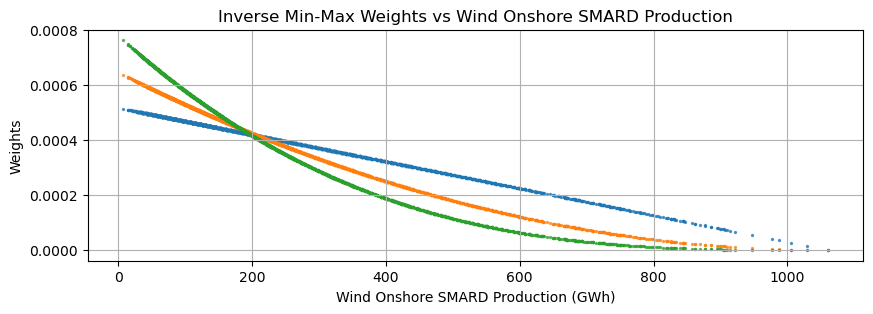

In [30]:
# Plot df['wind_onshore_SMARD'].values against weights in a scatter plot
plt.figure(figsize=(10, 3))
plt.scatter(train_df['wind_onshore_SMARD'].values, weights_0, s = 2, alpha=0.7)
plt.scatter(train_df['wind_onshore_SMARD'].values, weights_1, s = 2,alpha=0.7)
plt.scatter(train_df['wind_onshore_SMARD'].values, weights_2, s = 2, alpha=0.7)

plt.xlabel('Wind Onshore SMARD Production (GWh)')
plt.ylabel('Weights')
plt.title('Inverse Min-Max Weights vs Wind Onshore SMARD Production')
plt.grid(True)
plt.show()

In [31]:
params = [config.v_cutin0, config.v_cutout0, config.v_rated0]

def optimize_onshore(params, weights = weights_0):
    # years = range(2015, 2025)
    years = np.unique(train_combined_ds.time.dt.year.values)

    ts_list = []
    cutin_opt, cutout_opt, rated_opt = params

    for year in years:
        ds_year = train_combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')

        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)

        ds_year['wind_on_pot']  = wepot_on['pot']

        weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore[year])
        output = weprod_on['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)

        del ds_year
        gc.collect()

    # obs = train_df['wind_onshore_SMARD'].values   # make sure ordering matches ts_list ordering

    # IMPORTANT: ensure ts_list and obs are aligned and same length!
    rmse_wind_onshore = weighted_rmse(obs, ts_list, weights)
    rmse_wind_onshored_unweighted = root_mean_squared_error(train_df['wind_onshore_SMARD'], ts_list)
    print(f"Weighted RMSE: {rmse_wind_onshore}, Unweighted RMSE: {rmse_wind_onshored_unweighted}")
    return rmse_wind_onshore


In [32]:

def test_onshore(params, weights = weights_0):
    # years = range(2015, 2025)
    years = np.unique(test_combined_ds.time.dt.year.values)

    ts_list = []
    cutin_opt, cutout_opt, rated_opt = params

    for year in years:
        ds_year = test_combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')

        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)

        ds_year['wind_on_pot']  = wepot_on['pot']

        weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore[year])
        output = weprod_on['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)

        del ds_year
        gc.collect()

    # IMPORTANT: ensure ts_list and obs are aligned and same length!
    # rmse_wind_onshore = weighted_rmse(obs, ts_list, weights)
    rmse_wind_onshored_unweighted = root_mean_squared_error(test_df['wind_onshore_SMARD'], ts_list)
    # print(f"Weighted RMSE: {rmse_wind_onshore}, Unweighted RMSE: {rmse_wind_onshored_unweighted}")
    return rmse_wind_onshored_unweighted


In [33]:
# Old without weighting
'''params = [config.v_cutin0, config.v_cutout0, config.v_rated0]

def optimize_onshore(params):
    years = range(2015, 2025)

    ts_list = []          # weekly / standard demand
    cutin_opt, cutout_opt, rated_opt = params
    
    for year in years:
        ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()

        # compute wind potential using year-specific hub heights
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')
        
        # wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        # ds_year['wind_off_pot'] = wepot_off['pot']
        ds_year['wind_on_pot']  = wepot_on['pot']

        # compute energy production using year-specific capacity maps
        # weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore[year])
        weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on,  grid_onshore[year])
        output = weprod_on['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)
        del ds_year#, ds_weighted_temp, timeseries_ds, ts_output
        gc.collect()
    
    # mod_onshore = pd.concat(ts_list).to_series().reset_index(drop=True)
    
    rmse_wind_onshore = root_mean_squared_error(df['wind_onshore_SMARD'], ts_list)
    # print(f"params={params}, RMSE={rmse_wind_onshore}")
    return rmse_wind_onshore'''

'params = [config.v_cutin0, config.v_cutout0, config.v_rated0]\n\ndef optimize_onshore(params):\n    years = range(2015, 2025)\n\n    ts_list = []          # weekly / standard demand\n    cutin_opt, cutout_opt, rated_opt = params\n\n    for year in years:\n        ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()\n\n        # compute wind potential using year-specific hub heights\n        ds_year_sfcWind_ds = ds_year[\'sfcWind\'].to_dataset(name=\'sfcWind\')\n\n        # wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)\n        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)\n        # ds_year[\'wind_off_pot\'] = wepot_off[\'pot\']\n        ds_year[\'wind_on_pot\']

In [34]:
# With train_years = [2016, 2018, 2019, 2020, 2021, 2022, 2024]

result_onshore = minimize(
    optimize_onshore,   # <-- pass the function itself
    params              # initial guess
    # method="L-BFGS-B",   # good default
)
print(result_onshore.x)        # optimized parameters
print(result_onshore.fun)      # minimized RMSE
print(result_onshore.success)
print(result_onshore.message)

Weighted RMSE: 120.47553985662014, Unweighted RMSE: 130.36344603587048
Weighted RMSE: 120.47554005002405, Unweighted RMSE: 130.36344622703575
Weighted RMSE: 120.47553985662014, Unweighted RMSE: 130.36344603587048
Weighted RMSE: 120.47554020754063, Unweighted RMSE: 130.3634464308374
Weighted RMSE: 94.15727900448925, Unweighted RMSE: 104.5327305920655
Weighted RMSE: 94.15727917164698, Unweighted RMSE: 104.5327307424931
Weighted RMSE: 94.15727900448925, Unweighted RMSE: 104.5327305920655
Weighted RMSE: 94.1572793110615, Unweighted RMSE: 104.53273083260075
Weighted RMSE: 116.78237252945067, Unweighted RMSE: 152.55102992174278
Weighted RMSE: 116.78237250152931, Unweighted RMSE: 152.55102988945947
Weighted RMSE: 116.78237252945067, Unweighted RMSE: 152.55102992174278
Weighted RMSE: 116.78237169243235, Unweighted RMSE: 152.55102895966846
Weighted RMSE: 80.87058669419018, Unweighted RMSE: 99.22559295809282
Weighted RMSE: 80.87058680847649, Unweighted RMSE: 99.22559304099737
Weighted RMSE: 80.8

In [35]:
# With test_years = [2015, 1017, 2023]
params = result_onshore.x
test_rmse_onshore = test_onshore(params)
print(f"Test RMSE with optimized parameters: {test_rmse_onshore}")

Test RMSE with optimized parameters: 78.58643083299229


In [ ]:
# With train_years = [2015, 2017, 2019, 2020, 2021, 2023, 2024]
result_onshore = minimize(
    optimize_onshore,   # <-- pass the function itself
    params              # initial guess
    # method="L-BFGS-B",   # good default
)
print(result_onshore.x)        # optimized parameters
print(result_onshore.fun)      # minimized RMSE
print(result_onshore.success)
print(result_onshore.message)

Weighted RMSE: 119.6828223474356, Unweighted RMSE: 130.04223008136037
Weighted RMSE: 119.68282253893453, Unweighted RMSE: 130.04223027031247
Weighted RMSE: 119.6828223474356, Unweighted RMSE: 130.04223008136037
Weighted RMSE: 119.68282270448985, Unweighted RMSE: 130.0422304770942
Weighted RMSE: 93.55255729059749, Unweighted RMSE: 105.06898596809071
Weighted RMSE: 93.55255745327594, Unweighted RMSE: 105.06898611250617
Weighted RMSE: 93.55255729059749, Unweighted RMSE: 105.06898596809071
Weighted RMSE: 93.55255758264457, Unweighted RMSE: 105.06898617541677
Weighted RMSE: 97.46121585014676, Unweighted RMSE: 130.49517195605097
Weighted RMSE: 97.46121584984144, Unweighted RMSE: 130.49517195331472
Weighted RMSE: 97.46121585014676, Unweighted RMSE: 130.49517195605097
Weighted RMSE: 97.46121519420531, Unweighted RMSE: 130.49517114081368
Weighted RMSE: 78.68570852964396, Unweighted RMSE: 99.79704768996177
Weighted RMSE: 78.68570859177284, Unweighted RMSE: 99.79704773231434
Weighted RMSE: 78.685

In [ ]:
# With test_years = [2016, 1018, 2022]
params = result_onshore.x
test_rmse_onshore = test_onshore(params)
print(f"Test RMSE with optimized parameters: {test_rmse_onshore}")

Test RMSE with optimized parameters: 92.29013329598348


In [ ]:
# With range(2015, 2023)

result_onshore = minimize(
    optimize_onshore,   # <-- pass the function itself
    params              # initial guess
    # method="L-BFGS-B",   # good default
)
print(result_onshore.x)        # optimized parameters
print(result_onshore.fun)      # minimized RMSE
print(result_onshore.success)
print(result_onshore.message)

Weighted RMSE: 110.18934952441559, Unweighted RMSE: 119.70212114586113
Weighted RMSE: 110.18934970356374, Unweighted RMSE: 119.70212132328413
Weighted RMSE: 110.18934952441559, Unweighted RMSE: 119.70212114586113
Weighted RMSE: 110.18934984565881, Unweighted RMSE: 119.70212151698009
Weighted RMSE: 85.98047207908797, Unweighted RMSE: 95.76330598752371
Weighted RMSE: 85.9804722341691, Unweighted RMSE: 95.76330612660495
Weighted RMSE: 85.98047207908797, Unweighted RMSE: 95.76330598752371
Weighted RMSE: 85.98047236108796, Unweighted RMSE: 95.76330620204448
Weighted RMSE: 107.70549886470552, Unweighted RMSE: 143.38703951393552
Weighted RMSE: 107.70549883724044, Unweighted RMSE: 143.38703948261272
Weighted RMSE: 107.70549886470552, Unweighted RMSE: 143.38703951393552
Weighted RMSE: 107.70549808419386, Unweighted RMSE: 143.38703860651262
Weighted RMSE: 73.82304706889363, Unweighted RMSE: 91.66749645463213
Weighted RMSE: 73.82304717699385, Unweighted RMSE: 91.66749653155202
Weighted RMSE: 73.8

In [ ]:
# With range(2023, 2025)
params = result_onshore.x
test_rmse_onshore = test_onshore(params)
print(f"Test RMSE with optimized parameters: {test_rmse_onshore}")

Test RMSE with optimized parameters: 93.0256884923522


In [ ]:
result_onshore_weighted_1 = minimize(
    optimize_onshore,   # <-- pass the function itself
    params,              # initial guess
    args=(weights_0,)
    # method="L-BFGS-B",   # good default
)
print(result_onshore_weighted_1.x)        # optimized parameters
print(result_onshore_weighted_1.fun)      # minimized RMSE
print(result_onshore_weighted_1.success)
print(result_onshore_weighted_1.message)

result_onshore_weighted_2 = minimize(
    optimize_onshore,   # <-- pass the function itself
    params,              # initial guess
    args=(weights_1,)
    # method="L-BFGS-B",   # good default
)
print(result_onshore_weighted_2.x)        # optimized parameters
print(result_onshore_weighted_2.fun)      # minimized RMSE
print(result_onshore_weighted_2.success)
print(result_onshore_weighted_2.message)

result_onshore_weighted_3 = minimize(
    optimize_onshore,   # <-- pass the function itself
    params,              # initial guess
    args=(weights_2,)
    # method="L-BFGS-B",   # good default
)
print(result_onshore_weighted_3.x)        # optimized parameters
print(result_onshore_weighted_3.fun)      # minimized RMSE
print(result_onshore_weighted_3.success)
print(result_onshore_weighted_3.message)

[2.29954722e-03 2.50000000e+01 1.14878780e+01]
73.8492674419637
True
Optimization terminated successfully.
[-4.57411335 25.         12.13917408]
47.81502692308356
True
Optimization terminated successfully.
[-4.35075135 25.         11.9984012 ]
43.10030060752156
True
Optimization terminated successfully.


In [17]:
result_onshore_bound_1 = minimize(
    optimize_onshore,   # <-- pass the function itself
    params,              # initial guess
    method="L-BFGS-B",   # good default
    bounds=[
        (0, 7),      # v_cutin bounds +-3.5
        (20, 30),    # v_cutout bounds +-5
        (8, 18)      # v_rated bounds +-5
    ]
)

print(result_onshore_bound_1.x)        # optimized parameters
print(result_onshore_bound_1.fun)      # minimized RMSE
print(result_onshore_bound_1.success)
print(result_onshore_bound_1.message)


result_onshore_bound_2 = minimize(
    optimize_onshore,   # <-- pass the function itself
    params,              # initial guess
    method="L-BFGS-B",   # good default
    bounds=[
        (-7, 7),      # v_cutin bounds +-3.5
        (20, 30),    # v_cutout bounds +-5
        (8, 18)      # v_rated bounds +-5
    ]
)

print(result_onshore_bound_2.x)        # optimized parameters
print(result_onshore_bound_2.fun)      # minimized RMSE
print(result_onshore_bound_2.success)
print(result_onshore_bound_2.message)


[ 0.         25.         11.80177721]
91.12535169615006
True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[1.00792814e-02 2.50000000e+01 1.18018132e+01]
91.12535206868537
True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


### Test individual years with general parameters

In [ ]:
params = [2.29954722e-03, 2.50000000e+01, 1.14878780e+01]

In [39]:
for year in range(2015, 2025):
    years = np.unique(test_combined_ds.time.dt.year.values)

    ts_list = []
    cutin_opt, cutout_opt, rated_opt = [2.29954722e-03, 2.50000000e+01, 1.14878780e+01]


    ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
    ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')

    wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)

    ds_year['wind_on_pot']  = wepot_on['pot']

    weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore[year])
    output = weprod_on['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        # ts_list.extend(output.values)

        # del ds_year
        # gc.collect()
    df_year = df[df['date'].dt.year == year].reset_index(drop=True)
    # IMPORTANT: ensure ts_list and obs are aligned and same length!
    # rmse_wind_onshore = weighted_rmse(obs, ts_list, weights)
    rmse_wind_onshored_unweighted = root_mean_squared_error(df_year['wind_onshore_SMARD'], output.values)
    # print(f"Weighted RMSE: {rmse_wind_onshore}, Unweighted RMSE: {rmse_wind_onshored_unweighted}")
    print(year, ':', rmse_wind_onshored_unweighted)

2015 : 70.25030542026933
2016 : 63.082120524905605
2017 : 76.39521088417628
2018 : 77.47620757445198
2019 : 90.85222556721436
2020 : 95.45887555557147
2021 : 80.95054559546476
2022 : 114.31203987696597
2023 : 128.57766881130223
2024 : 111.77258611986456


In [ ]:

def test_onshore(params, weights = weights_0):
    # years = range(2015, 2025)
    years = np.unique(test_combined_ds.time.dt.year.values)

    ts_list = []
    cutin_opt, cutout_opt, rated_opt = params

    for year in years:
        ds_year = test_combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')

        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)

        ds_year['wind_on_pot']  = wepot_on['pot']

        weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore[year])
        output = weprod_on['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)

        del ds_year
        gc.collect()

    # IMPORTANT: ensure ts_list and obs are aligned and same length!
    # rmse_wind_onshore = weighted_rmse(obs, ts_list, weights)
    rmse_wind_onshored_unweighted = root_mean_squared_error(test_df['wind_onshore_SMARD'], ts_list)
    # print(f"Weighted RMSE: {rmse_wind_onshore}, Unweighted RMSE: {rmse_wind_onshored_unweighted}")
    return rmse_wind_onshored_unweighted


### Offshore

In [18]:
params = [config.v_cutin0, config.v_cutout0, config.v_rated0]

def optimize_offshore(params):
    years = range(2015, 2025)

    ts_list = []          # weekly / standard demand
    cutin_opt, cutout_opt, rated_opt = params
    
    for year in years:
        # print(f"\n=== Processing year {year} ===")
        # run_time = time.time()

        # slice the dataset to this calendar year
        ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()

        # compute wind potential using year-specific hub heights
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')
        
        wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        # wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        ds_year['wind_off_pot'] = wepot_off['pot']
        # ds_year['wind_on_pot']  = wepot_on['pot']

        # compute energy production using year-specific capacity maps
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore[year])
        # weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on,  grid_onshore[year])
        output = weprod_off['prod'].sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)
        del ds_year#, ds_weighted_temp, timeseries_ds, ts_output
        gc.collect()
    
    # mod_offshore = pd.concat(ts_list).to_series().reset_index(drop=True)
    
    rmse_wind_offshore = root_mean_squared_error(df['wind_offshore_SMARD'], ts_list)
    # print(f"params={params}, RMSE={rmse_wind_offshore}")
    return rmse_wind_offshore

In [19]:
result_offshore = minimize(
    optimize_offshore,   # <-- pass the function itself
    params#,              # initial guess
    # method="L-BFGS-B",   # good default
)
print(result_offshore.x)        # optimized parameters
print(result_offshore.fun)      # minimized RMSE
print(result_offshore.success)
print(result_offshore.message)

[8.39701209e-03 2.50000000e+01 1.41507522e+01]
31.258463893215993
True
Optimization terminated successfully.


In [20]:
'''result_offshore_bound_1 = minimize(
    optimize_offshore,   # <-- pass the function itself
    params,              # initial guess
    # method="L-BFGS-B",   # good default
    bounds=[
        (0, 7),      # v_cutin bounds +-3.5
        (20, 30),    # v_cutout bounds +-5
        (8, 18)      # v_rated bounds +-5
    ]
)
print(result_offshore_bound_1.x)        # optimized parameters
print(result_offshore_bound_1.fun)      # minimized RMSE
print(result_offshore_bound_1.success)
print(result_offshore_bound_1.message)

result_offshore_bound_2 = minimize(
    optimize_offshore,   # <-- pass the function itself
    params,              # initial guess
    # method="L-BFGS-B",   # good default
    bounds=[
        (0, None),      # v_cutin bounds
        (0, None),    # v_cutout bounds 
        (0, None)      # v_rated bounds 
    ]
)
print(result_offshore_bound_2.x)        # optimized parameters
print(result_offshore_bound_2.fun)      # minimized RMSE
print(result_offshore_bound_2.success)
print(result_offshore_bound_2.message)'''

'result_offshore_bound_1 = minimize(\n    optimize_offshore,   # <-- pass the function itself\n    params,              # initial guess\n    # method="L-BFGS-B",   # good default\n    bounds=[\n        (0, 7),      # v_cutin bounds +-3.5\n        (20, 30),    # v_cutout bounds +-5\n        (8, 18)      # v_rated bounds +-5\n    ]\n)\nprint(result_offshore_bound_1.x)        # optimized parameters\nprint(result_offshore_bound_1.fun)      # minimized RMSE\nprint(result_offshore_bound_1.success)\nprint(result_offshore_bound_1.message)\n\nresult_offshore_bound_2 = minimize(\n    optimize_offshore,   # <-- pass the function itself\n    params,              # initial guess\n    # method="L-BFGS-B",   # good default\n    bounds=[\n        (0, None),      # v_cutin bounds\n        (0, None),    # v_cutout bounds \n        (0, None)      # v_rated bounds \n    ]\n)\nprint(result_offshore_bound_2.x)        # optimized parameters\nprint(result_offshore_bound_2.fun)      # minimized RMSE\nprint(res

### Optimize solar

In [21]:

params = [config.cT_c1, config.cT_c2, config.cT_c3, config.cT_c4, config.gamma, config.temp_ref]

# cT_c1 = 4.3  # constant [dC]
# cT_c2 = 0.943  # constant [-]
# cT_c3 = 0.028  # constant [dC m2 W-1]
# cT_c4 = -1.528  # constant [dC s m-1]
# gamma = -0.005  # constant [--]
# temp_ref = 25  # reference temperature [dC]


def optimize_solar(params):
    years = range(2015, 2025)

    ts_list = []          # weekly / standard demand
    cT_c1_opt, cT_c2_opt, cT_c3_opt, cT_c4_opt, gamma_opt, temp_ref_opt = params
    
    for year in years:
        # print(f"\n=== Processing year {year} ===")
        # run_time = time.time()

        # slice the dataset to this calendar year
        ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()
        
        # 5) solar potential & production with year-specific solar capacity
        pv_constants = [cT_c1_opt, cT_c2_opt, cT_c3_opt, cT_c4_opt]
        sepot = solar_model_func.compute_solar_energy_potential(ds_year['rsds'], ds_year['tas'], ds_year['tasmax'], ds_year['sfcWind'], constants=pv_constants, gamma=gamma_opt, ref_temp=temp_ref_opt)
        ds_year['solar_pot'] = sepot
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar[year])
        ds_year['solar_prod'] = seprod

        # # compute wind potential using year-specific hub heights
        # ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')
        
        # wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        # # wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_opt, v_rated=rated_opt, v_cutout=cutout_opt)
        # ds_year['wind_off_pot'] = wepot_off['pot']
        # # ds_year['wind_on_pot']  = wepot_on['pot']

        # # compute energy production using year-specific capacity maps
        # weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore[year])
        # # weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on,  grid_onshore[year])
        output = seprod.sum(dim=['lat', 'lon']) / 1_000_000
        ts_list.extend(output.values)
        del ds_year#, ds_weighted_temp, timeseries_ds, ts_output
        gc.collect()
    
    # mod_offshore = pd.concat(ts_list).to_series().reset_index(drop=True)
    
    rmse_solar = root_mean_squared_error(df['solar_SMARD'], ts_list)
    # print(f"params={params}, RMSE={rmse_solar}")
    return rmse_solar

In [22]:
result_solar = minimize(
    optimize_solar,   # <-- pass the function itself
    params#,              # initial guess
    # method="L-BFGS-B",   # good default
)
print(result_solar.x)        # optimized parameters
print(result_solar.fun)      # minimized RMSE
print(result_solar.success)
print(result_solar.message)

[ 5.96473933e+01  5.42857790e-01  8.64680503e-03  4.59579472e+00
 -2.40438135e-03 -3.03472531e+01]
22.57659134973196
False
Desired error not necessarily achieved due to precision loss.


In [19]:
print(5.96473933e+01, 5.42857790e-01, 8.64680503e-03, 4.59579472e+00, -2.40438135e-03, -3.03472531e+01)

59.6473933 0.54285779 0.00864680503 4.59579472 -0.00240438135 -30.3472531


In [ ]:
'''result_solar_bound = minimize(
    optimize_solar,   # <-- pass the function itself
    params,              # initial guess
    # method="L-BFGS-B",   # good default
    bounds=[
        (0, 20),      # cT_c1 bounds
        (None, None),      # cT_c2 bounds
        (None, None),      # cT_c3 bounds
        (None, None),      # cT_c4 bounds
        (None, None),    # gamma bounds
        (20, 30)      # temp_ref bounds
    ]
)

# cT_c1 = 4.3  # constant [dC]
# cT_c2 = 0.943  # constant [-]
# cT_c3 = 0.028  # constant [dC m2 W-1]
# cT_c4 = -1.528  # constant [dC s m-1]
# gamma = -0.005  # constant [--]
# temp_ref = 25  # reference temperature [dC]

print(result_solar_bound.x)        # optimized parameters
print(result_solar_bound.fun)      # minimized RMSE
print(result_solar_bound.success)
print(result_solar_bound.message)'''

[ 4.36911129e+00  1.75307377e+00  1.99218378e+01 -1.27021225e+00
 -3.72054941e-05  2.49308887e+01]
25.316527231139112
True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


## Check results

In [86]:
def SEM_run(cutin_off, cutout_off, rated_off, cutin_on, cutout_on, rated_on, cT_c1, cT_c2, cT_c3, cT_c4, gamma, temp_ref, df_internal):
    years = range(2015, 2025)
    
    ts_list = []          # weekly / standard demand
    ts_list_wwd = []      # weekday/weekend variant (optional)
    
    for year in years:
        # print(f"\n=== Processing year {year} ===")
        # run_time = time.time()

        # 1) slice the big combined dataset to this calendar year
        ds_year = combined_ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31")).copy()

        # 3) compute wind potential using year-specific hub heights
        ds_year_sfcWind_ds = ds_year['sfcWind'].to_dataset(name='sfcWind')
        
        wepot_off = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_offshore_hh[year], config.a_offshore, config.height_ref, v_cutin=cutin_off, v_rated=rated_off, v_cutout=cutout_off)
        wepot_on = wind_model_func.compute_wind_energy_potential(ds_year_sfcWind_ds, grid_onshore_hh[year], config.a_onshore, config.height_ref, v_cutin=cutin_on, v_rated=rated_on, v_cutout=cutout_on)
        ds_year['wind_off_pot'] = wepot_off['pot']
        ds_year['wind_on_pot']  = wepot_on['pot']

        # 4) compute energy production using year-specific capacity maps
        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore[year])
        weprod_on  = wind_model_func.compute_wind_energy_production(wepot_on,  grid_onshore[year])

        ds_year['wind_off_prod'] = weprod_off['prod']
        ds_year['wind_on_prod']  = weprod_on['prod']

        # 5) solar potential & production with year-specific solar capacity
        constants = [cT_c1, cT_c2, cT_c3, cT_c4]
        sepot = solar_model_func.compute_solar_energy_potential(ds_year['rsds'], ds_year['tas'], ds_year['tasmax'], ds_year['sfcWind'], constants=constants, gamma=gamma, ref_temp=temp_ref)
        ds_year['solar_pot'] = sepot
        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar[year])
        ds_year['solar_prod'] = seprod

        # 6) population-weighted temperature time series for this year
        # (since ds_year contains only this year, we don't need the previous "loop over unique years")
        ds_weighted_temp = xr.Dataset()
        # sum over lat/lon weighted by population regridded weights
        ds_weighted_temp['temp'] = (ds_year['tas'] * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])

        # 7) demand (weekly fit) for this year's weighted temp
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country=9, period='week'))
        timeseries_ds = demand_ds.copy()

        # 8) build timeseries aggregates (masked area means + production sums)
        timeseries_ds['sfcWind'] = ds_year['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = ds_year['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = ds_year['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = ds_year['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

        timeseries_ds['wind_off_prod'] = ds_year['wind_off_prod'].sum(dim=['lat', 'lon']) / 1_000_000
        timeseries_ds['wind_on_prod']  = ds_year['wind_on_prod'].sum(dim=['lat', 'lon'])  / 1_000_000
        timeseries_ds['solar_prod']    = ds_year['solar_prod'].sum(dim=['lat', 'lon'])      / 1_000_000

        timeseries_ds['total_prod']     = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto']          = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load']  = timeseries_ds['demand'] - timeseries_ds['total_prod']

        # 9) assign coords / metadata and save per-year
        ts_output = timeseries_ds.assign_coords(run='hist', ESM='ERA5_week', ESM_run='ERA5_hist_week')


        ts_output.load()  # ensure in-memory before writing
        # outpath = f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries_{year}.nc'
        # ts_output.to_netcdf(outpath)
        # print(f'  -> wrote timeseries to {outpath}')
        # print('  Run time: ', int(np.floor((time.time() - run_time) / 60)), 'm', round((time.time() - run_time) % 60, 1), 's')

        ts_output = timeseries_ds.assign_coords(
            run=run if ESM != "ERA5" else "hist",
            ESM=ESM,
            ESM_run=f"{ESM}_{run}",
        )

        # Ensure clean time axis (important!)
        ts_output = ts_output.sortby("time")

        ts_list.append(ts_output)
        
        # 10) weekday/weekend demand variant (wwd)
        ds_weighted_temp_w = xr.concat(
            [
                ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] < 5, drop=True),
                ds_weighted_temp.where(ds_weighted_temp["time.dayofweek"] >= 5, drop=True),
            ],
            "period",
        )
        ds_weighted_temp_w["period"] = ["weekday", "weekend"]
        ds_weighted_temp_w.load()

        demand_weekday = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekday'), demand_fit_values.sel(country=9, period='weekday'))
        demand_weekend = demand_func.compute_demand(ds_weighted_temp_w.sel(period='weekend'), demand_fit_values.sel(country=9, period='weekend'))
        demand_ds_wwd = (demand_weekday).fillna(0) + (demand_weekend).fillna(0)

        timeseries_ds = demand_ds_wwd.copy()
        timeseries_ds['sfcWind'] = ds_year['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = ds_year['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = ds_year['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = ds_year['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

        timeseries_ds['wind_off_prod'] = ds_year['wind_off_prod'].sum(dim=['lat', 'lon']) / 1_000_000
        timeseries_ds['wind_on_prod']  = ds_year['wind_on_prod'].sum(dim=['lat', 'lon'])  / 1_000_000
        timeseries_ds['solar_prod']    = ds_year['solar_prod'].sum(dim=['lat', 'lon'])      / 1_000_000
        timeseries_ds['total_prod']    = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto']         = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

        ts_output = timeseries_ds.assign_coords(run='hist', ESM=f'{ESM}_wwd', ESM_run=f'{ESM}_hist_wwd', period='wwd')
        ts_output.load()
        # outpath_wwd = f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_timeseries_wwd_{year}.nc'
        # ts_output.to_netcdf(outpath_wwd)
        # print(f'  -> wrote weekday/weekend timeseries to {outpath_wwd}')
        # print('  Run time: ', int(np.floor((time.time() - run_time) / 60)), 'm', round((time.time() - run_time) % 60, 1), 's')
        
        ts_output_wwd = timeseries_ds.assign_coords(
            run="hist",
            ESM=f"{ESM}_wwd",
            ESM_run=f"{ESM}_hist_wwd",
            period="wwd",
        )

        ts_output_wwd = ts_output_wwd.sortby("time")
        ts_list_wwd.append(ts_output_wwd)


        # 11) cleanup
        del ds_year, ds_weighted_temp, ds_weighted_temp_w, timeseries_ds, ts_output
        gc.collect()
        
    ts_full = xr.concat(ts_list, dim="time")

    # safety: remove duplicate timestamps if any
    _, index = np.unique(ts_full["time"], return_index=True)
    ts_full = ts_full.isel(time=index)

    ts_full.load()
    # ts_full.to_netcdf(f"/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries_yearly_new.nc")


    # ts_full_wwd = xr.concat(ts_list_wwd, dim="time")

    # _, index = np.unique(ts_full_wwd["time"], return_index=True)
    # ts_full_wwd = ts_full_wwd.isel(time=index)

    # ts_full_wwd.load()
    # ts_full_wwd.to_netcdf(f"/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_timeseries_wwd_yearly_new.nc")
    # print(ts_full.time.min().values, ts_full.time.max().values)
    # print(ts_full.dims)
    df_internal = df_internal.copy(deep=True)
    df_internal['wind_offshore_ERA5'] = ts_full['wind_off_prod'].values
    df_internal['wind_onshore_ERA5'] = ts_full['wind_on_prod'].values
    df_internal['solar_ERA5'] = ts_full['solar_prod'].values
    df_internal['total_production_ERA5'] = df_internal['wind_offshore_ERA5'] + df_internal['wind_onshore_ERA5'] + df_internal['solar_ERA5']

    return df_internal #, ts_full_wwd


In [102]:
df_original = SEM_run(
    cutin_off=config.v_cutin0,
    cutout_off=config.v_cutout0,
    rated_off=config.v_rated0,
    cutin_on=config.v_cutin0,
    cutout_on=config.v_cutout0,
    rated_on=config.v_rated0,
    cT_c1=config.cT_c1,
    cT_c2=config.cT_c2,
    cT_c3=config.cT_c3,
    cT_c4=config.cT_c4,
    gamma=config.gamma,
    temp_ref=config.temp_ref,
    df_internal=df
)

,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,total_production_SMARD,wind_offshore_model,wind_onshore_model,solar_model,total_production_model
0,2015-01-01,12.50850,298.79175,17.08025,328.38050,NaN,NaN,NaN,NaN
1,2015-01-02,10.32925,591.62075,7.75900,609.70900,NaN,NaN,NaN,NaN
2,2015-01-03,12.11950,457.04350,7.23475,476.39775,NaN,NaN,NaN,NaN
3,2015-01-04,11.53850,379.02950,19.98250,410.55050,NaN,NaN,NaN,NaN
4,2015-01-05,7.74550,219.62350,26.52225,253.89125,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3648,2024-12-27,2.94125,46.42200,61.20575,110.56900,NaN,NaN,NaN,NaN
3649,2024-12-28,22.34775,31.44225,61.08850,114.87850,NaN,NaN,NaN,NaN
3650,2024-12-29,97.29825,257.39450,39.71900,394.41175,NaN,NaN,NaN,NaN
3651,2024-12-30,61.18675,534.34725,22.92750,618.46150,NaN,NaN,NaN,NaN


In [89]:
df_unweighted = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore.x[0],
    cutout_on=result_onshore.x[1],
    rated_on=result_onshore.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

In [92]:
df_weighted_1 = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore_weighted_1.x[0],
    cutout_on=result_onshore_weighted_1.x[1],
    rated_on=result_onshore_weighted_1.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

df_weighted_2 = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore_weighted_2.x[0],
    cutout_on=result_onshore_weighted_2.x[1],
    rated_on=result_onshore_weighted_2.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

df_weighted_3 = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore_weighted_3.x[0],
    cutout_on=result_onshore_weighted_3.x[1],
    rated_on=result_onshore_weighted_3.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

df_bound_1 = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore_bound_1.x[0],
    cutout_on=result_onshore_bound_1.x[1],
    rated_on=result_onshore_bound_1.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

df_bound_2 = SEM_run(
    cutin_off=result_offshore.x[0],
    cutout_off=result_offshore.x[1],
    rated_off=result_offshore.x[2],
    cutin_on=result_onshore_bound_2.x[0],
    cutout_on=result_onshore_bound_2.x[1],
    rated_on=result_onshore_bound_2.x[2],
    cT_c1=result_solar.x[0],
    cT_c2=result_solar.x[1],
    cT_c3=result_solar.x[2],
    cT_c4=result_solar.x[3],
    gamma=result_solar.x[4],
    temp_ref=result_solar.x[5],
    df_internal=df)

In [67]:
result_onshore_bound_1.x[0]

np.float64(0.0)

In [68]:
result_onshore_bound_2.x[0]

np.float64(0.01007928139540696)

In [66]:
# Check if two objects are the same df_bound_1 and df_bound_2
print(df_bound_1 is df_bound_2)  # This will print True if they

True


In [106]:
def plot_all(df, setlim=False, maintitle=None):
    rows = [
        "wind_onshore",
        # 'wind_onshore_cor',
        "wind_offshore",
        # "wind_offshore_cor",
        "solar",
        # "solar_cor",
        "total_production",
        # "total_production_cor"
    ]
    cols = ["whole_year", "winter", 'perc']

    # Create empty DataFrame (filled with NaN)
    metrics = pd.DataFrame(index=rows, columns=cols)
    
    # --- Make all text bigger (global defaults) ---

    mpl.rcParams.update({
        'font.size': 14+2,             # base font size (affects legends, labels, etc. unless overridden)
        'axes.titlesize': 18+2,        # axes title
        'axes.labelsize': 16+2,        # x/y labels
        'xtick.labelsize': 14+2,       # x tick labels
        'ytick.labelsize': 14+2,       # y tick labels
        'legend.fontsize': 16+2,       # legend text
        'figure.titlesize': 20+2,      # figure title (if used)
    })

    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    if maintitle:
        fig.suptitle(maintitle, fontsize=22, fontweight='bold')
    plot_specs = [
        ('wind_onshore_SMARD', 'wind_onshore_ERA5', 'Onshore Wind Production'),
        ('wind_offshore_SMARD', 'wind_offshore_ERA5', 'Offshore Wind Production'),
        ('solar_SMARD', 'solar_ERA5', 'Solar Production'),
        ('total_production_SMARD', 'total_production_ERA5', 'Total Renewable Production')
    ]

    subplot_labels = ['(a)', '(b)', '(c)', '(d)']

    for idx, (ax, (col_smard, col_era5, title)) in enumerate(zip(axs.flat, plot_specs)):
        top = col_smard[0:-6]
        # top_cor = col_smard[0:-6] + '_cor'

        sns.scatterplot(x=col_smard, y=col_era5, data=df, alpha=0.6, ax=ax)
        
        # Regression line
        sns.regplot(x=col_smard, y=col_era5, data=df, scatter=False, color='black',
                    line_kws={'linewidth': 1.5, 'alpha': 0.7}, ax=ax)
        
        # 1:1 line
        min_val = min(df[col_smard].min(), df[col_era5].min())
        max_val = max(df[col_smard].max(), df[col_era5].max())
        ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

        # Adjust axes
        xrange = df[col_smard].max() - df[col_smard].min()
        min_ERA5 = df[col_era5].min()
        max_ERA5 = df[col_era5].max()
        yrange_ERA5 = max_ERA5 - min_ERA5
        ax.set_xlim(df[col_smard].min() - xrange * 0.03, df[col_smard].max() + xrange * 0.03)
        ax.set_ylim(min_ERA5 - xrange * 0.03, max_ERA5 + xrange * 0.03)
        
        if setlim:
            ax.set_ylim(0, yrange_ERA5/4)
            ax.set_xlim(0, yrange_ERA5/4)


        # Metrics
        r, _ = pearsonr(df[col_smard], df[col_era5])
        rmse = np.sqrt(np.mean((df[col_smard] - df[col_era5])**2))
        metrics.loc[top, 'whole_year'] = rmse
        # metrics.loc[top_cor, 'whole_year'] = rmse_corrected

        # Plot labels, titles (made larger)
        ax.set_xlabel(f'{title}\n- SMARD (GWh/day)')
        ax.set_ylabel(f'{title}\n- SEM (GWh/day)')
        ax.set_title(subplot_labels[idx], loc='left', fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)

        textstr = '\n'.join((
                f'RMSE = {rmse:.2f}',
                f'Pearson r = {r:.2f}'
            ))
        ax.text(0.98, 0.03, textstr, transform=ax.transAxes,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Create a common legend
    legend_elements = [
        Line2D([0], [0], linestyle='--', color='red', label='1:1 Line'),
        Line2D([0], [0], linestyle='-', color='black', label='Regression Line'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Data Points', alpha=0.6),
        # Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='Corrected Data Points', alpha=0.6),
    ]

    # Place common legend below all subplots (fontsize increased slightly)
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 0))

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for legend

    # Save the figure
    # plt.savefig('/home/onennecke/Code/Figures/Mod_eval_scatterplt.png', dpi=300, bbox_inches='tight')
    plt.show()


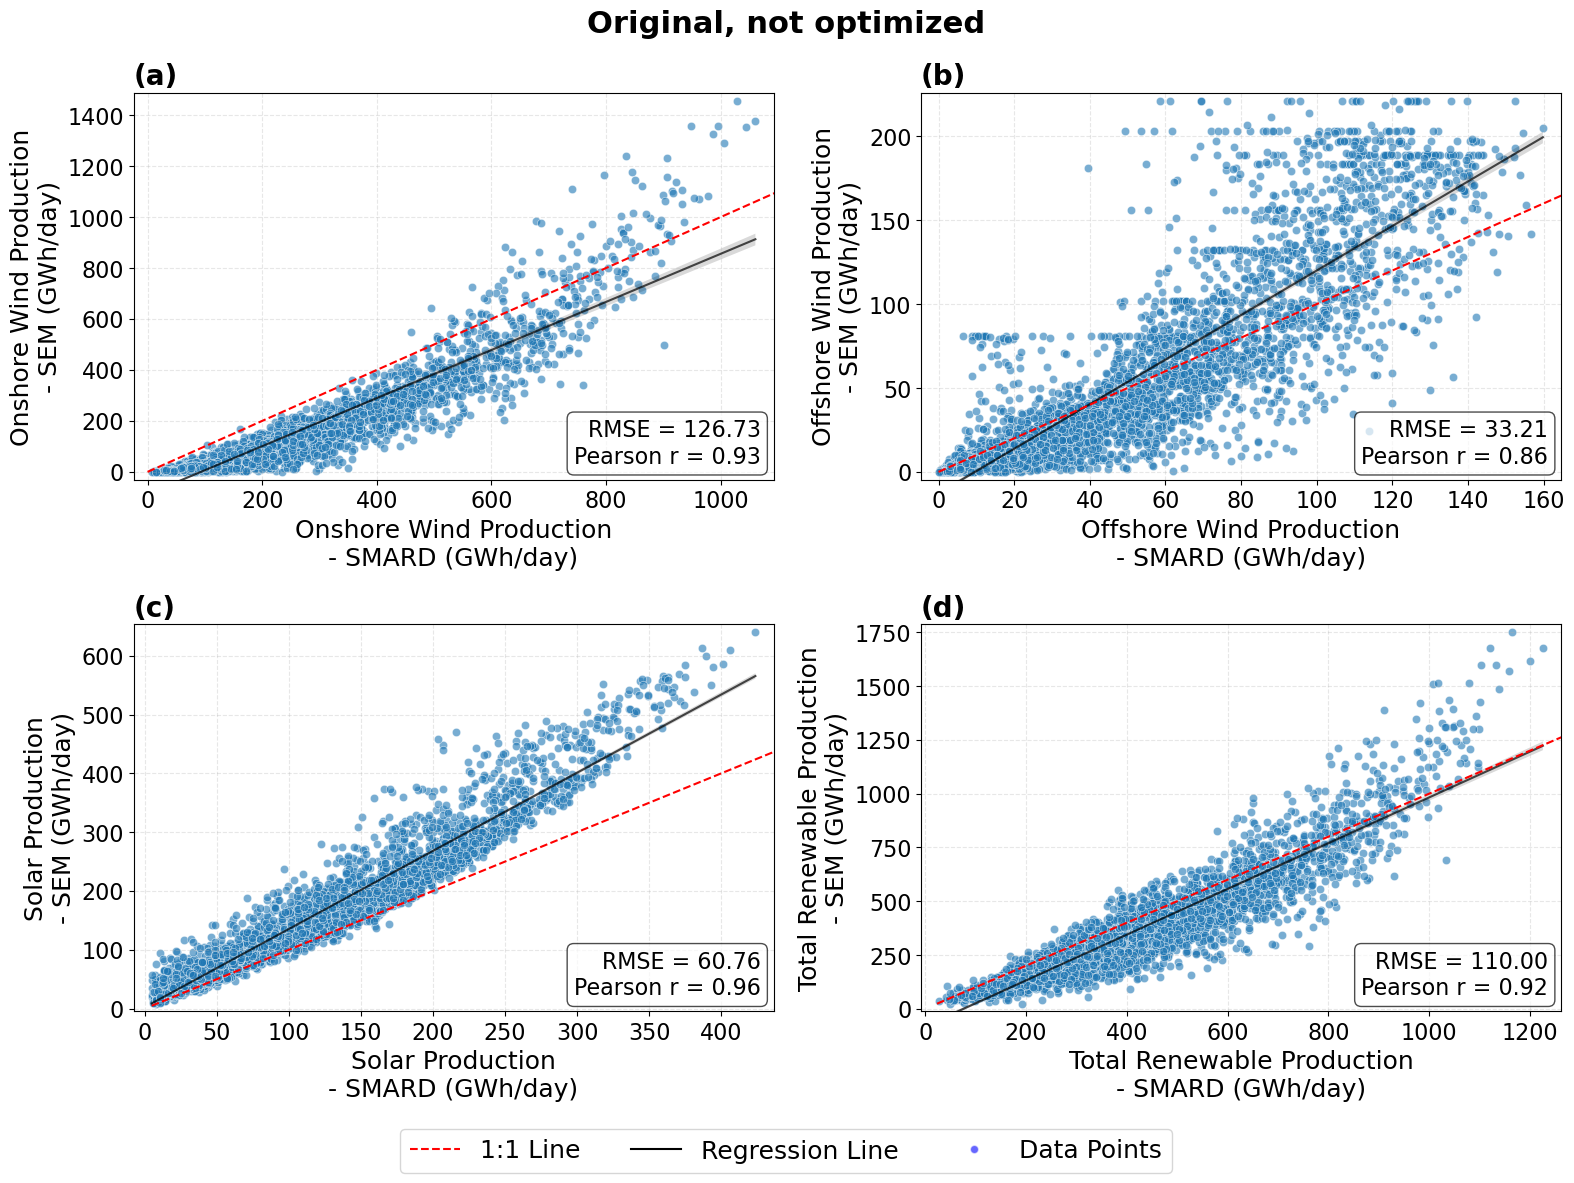

In [107]:
plot_all(df_original, setlim=False, maintitle='Original, not optimized')

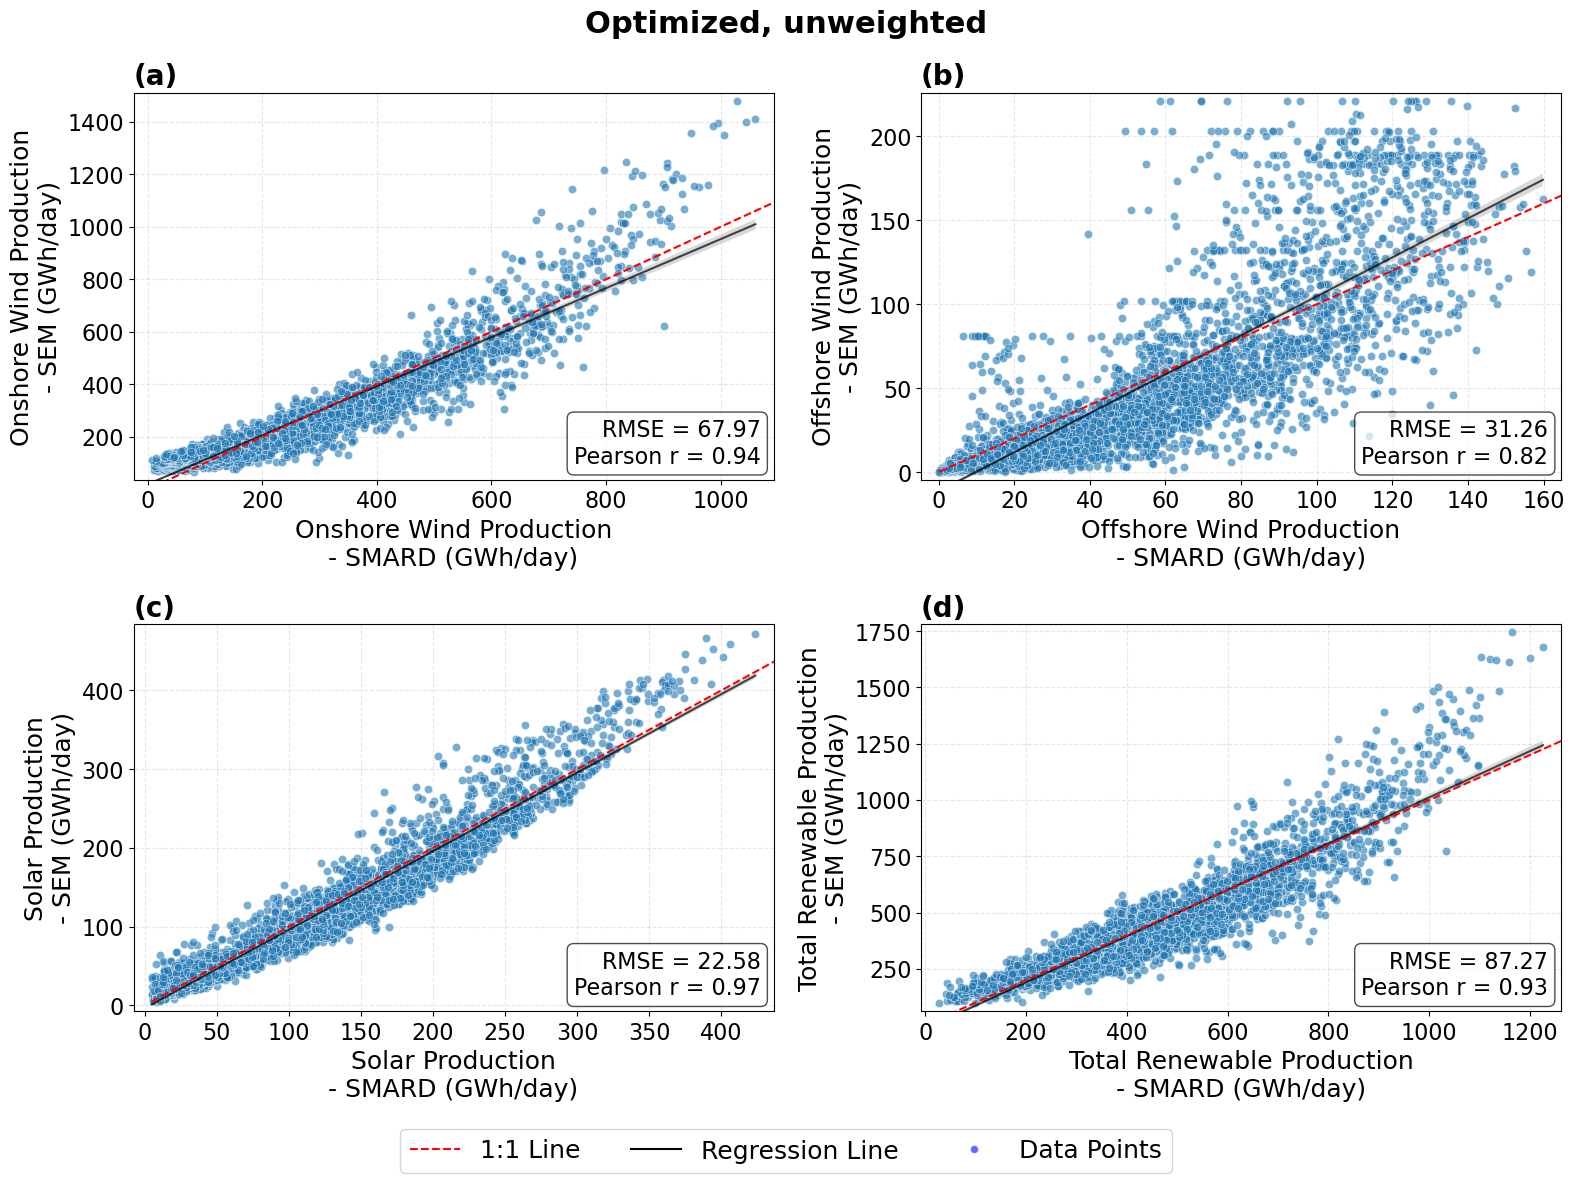

In [108]:
plot_all(df_unweighted, setlim=False, maintitle='Optimized, unweighted')

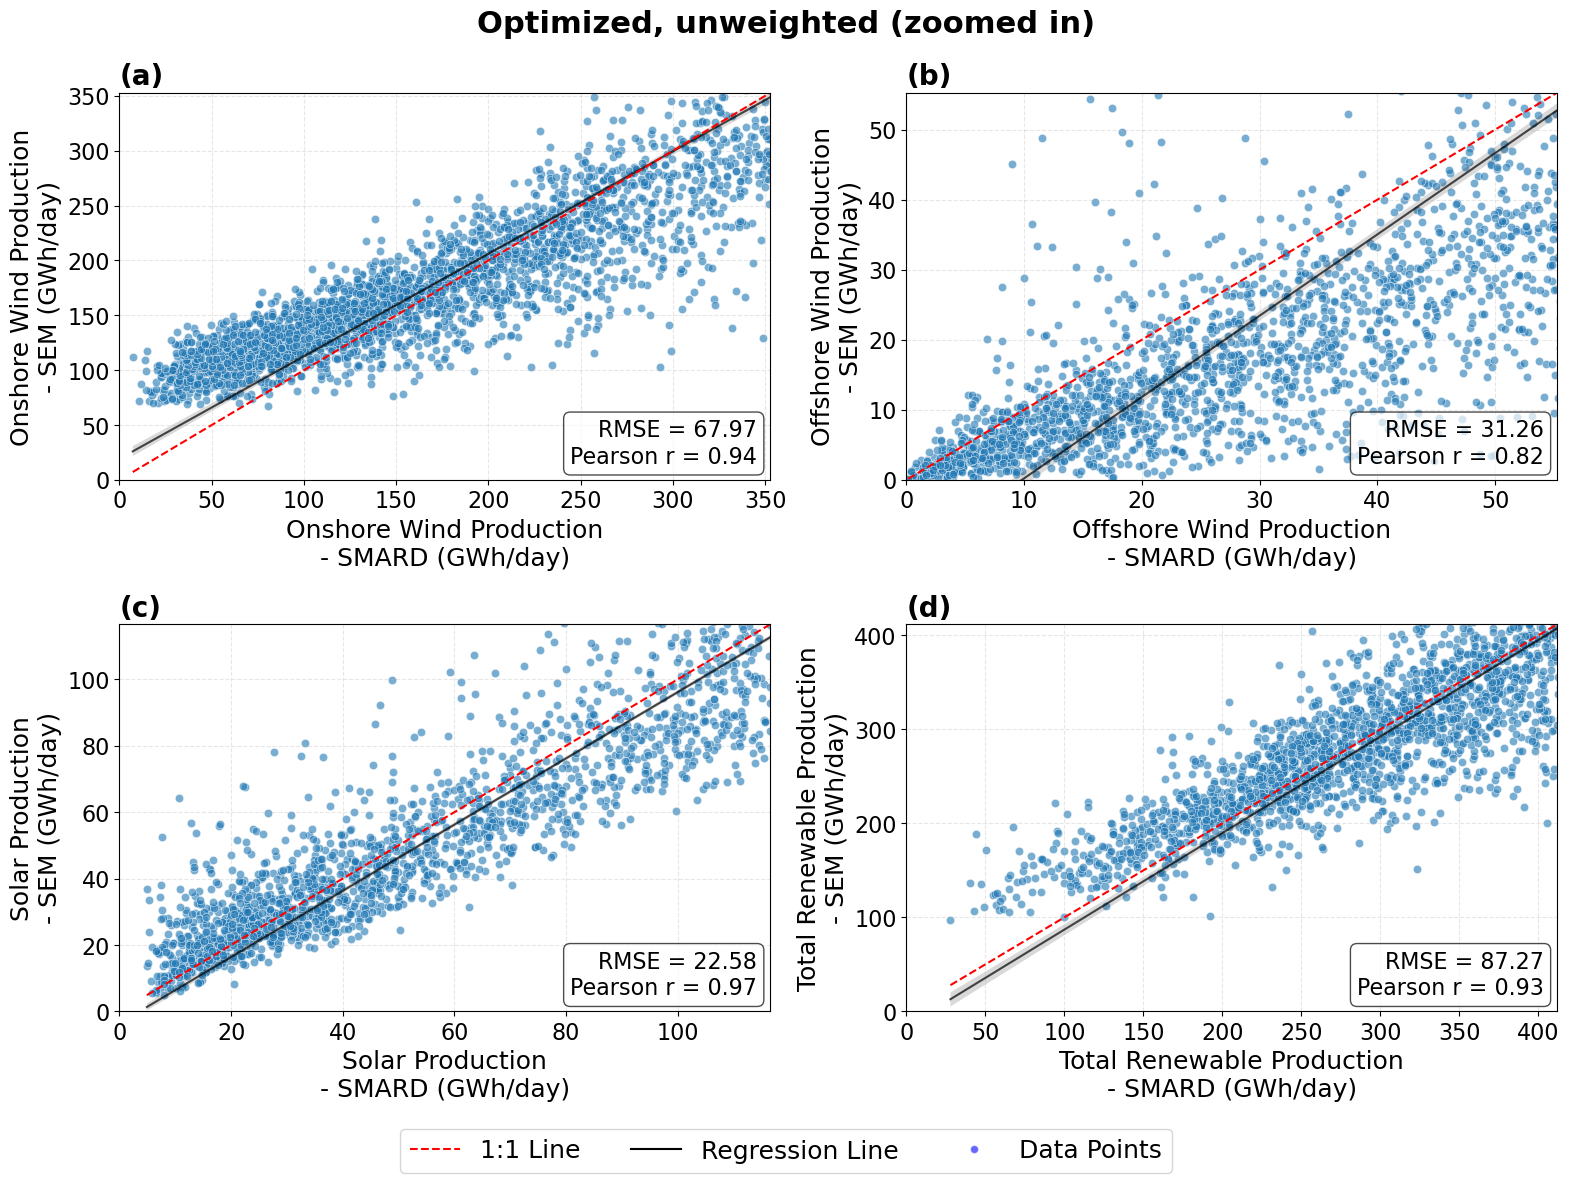

In [109]:
plot_all(df_unweighted, setlim=True, maintitle='Optimized, unweighted (zoomed in)')

In [123]:
def plot_onshore(df, maintitle, params=None):

    col_smard = 'wind_onshore_SMARD'
    col_era5 = 'wind_onshore_ERA5'

    # --- subset definition ---
    threshold = df[col_smard].quantile(0.4)
    threshold = 140

    df_subset = df[(df[col_smard] < threshold) & (df[col_era5] < threshold)]

    rows = ["wind_onshore", "wind_onshore_low"]
    metrics = pd.DataFrame(index=rows, columns=["whole_year"])

    # --- Make all text bigger ---
    mpl.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 20,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 18,
        'figure.titlesize': 22,
    })

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(maintitle, fontsize=22, fontweight='bold')
    
    # Print the parameters underneath the main title (if provided)
    if params is not None:
        param_text = f'\ncutin value = {round(params[0], 2)}, cutout value = {round(params[1], 2)}, rated value = {round(params[2], 2)}'
        fig.text(0.5, 0.92, param_text, ha='center', fontsize=16, fontstyle='italic')

    plot_specs = [
        (df, "Onshore Wind Production", "wind_onshore"),
        (df_subset, "Onshore Wind Production (Small values)", "wind_onshore_low")
    ]

    subplot_labels = ['(a)', '(b)']

    for idx, (ax, data, title, metric_key) in enumerate(
        (axs[i], *spec) for i, spec in enumerate(plot_specs)
    ):
        sns.scatterplot(x=col_smard, y=col_era5, data=data, alpha=0.6, ax=ax)

        # Regression line
        sns.regplot(
            x=col_smard, y=col_era5, data=data,
            scatter=False, color='black',
            line_kws={'linewidth': 1.5, 'alpha': 0.7},
            ax=ax
        )

        # 1:1 line
        min_val = min(data[col_smard].min(), data[col_era5].min())
        max_val = max(data[col_smard].max(), data[col_era5].max())
        ax.plot([min_val, max_val], [min_val, max_val],
                color='red', linestyle='--')

        # Axis limits
        xrange = data[col_smard].max() - data[col_smard].min()
        ax.set_xlim(0,
                    data[col_smard].max() + 0.03 * xrange)
        ax.set_ylim(0,
                    data[col_era5].max() + 0.03 * xrange)

        # Metrics
        r, _ = pearsonr(data[col_smard], data[col_era5])
        rmse = np.sqrt(np.mean((data[col_smard] - data[col_era5])**2))
        metrics.loc[metric_key, 'whole_year'] = rmse

        # Labels & text
        ax.set_xlabel(f'{title}\n– SMARD (GWh/day)')
        ax.set_ylabel(f'{title}\n– SEM (GWh/day)')
        ax.set_title(subplot_labels[idx], loc='left', fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)

        ax.text(
            0.98, 0.03,
            f'RMSE = {rmse:.2f}\nPearson r = {r:.2f}',
            transform=ax.transAxes,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', alpha=0.7)
        )

    # Common legend
    legend_elements = [
        Line2D([0], [0], linestyle='--', color='red', label='1:1 Line'),
        Line2D([0], [0], linestyle='-', color='black', label='Regression Line'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='blue', label='Data Points', alpha=0.6),
    ]

    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, frameon=True, bbox_to_anchor=(0.5, 0))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

    # return metrics


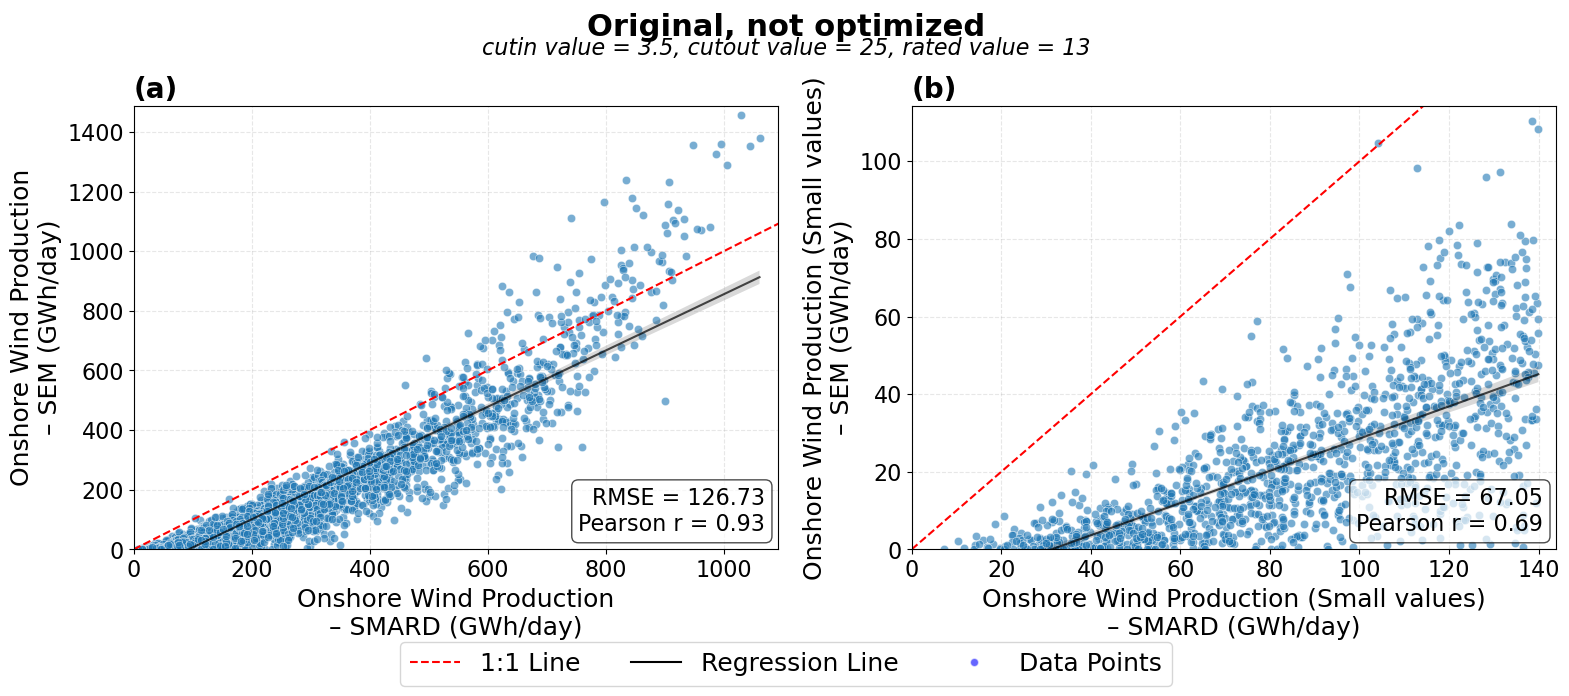

In [124]:
plot_onshore(df_original, maintitle='Original, not optimized', params=[config.v_cutin0, config.v_cutout0, config.v_rated0])

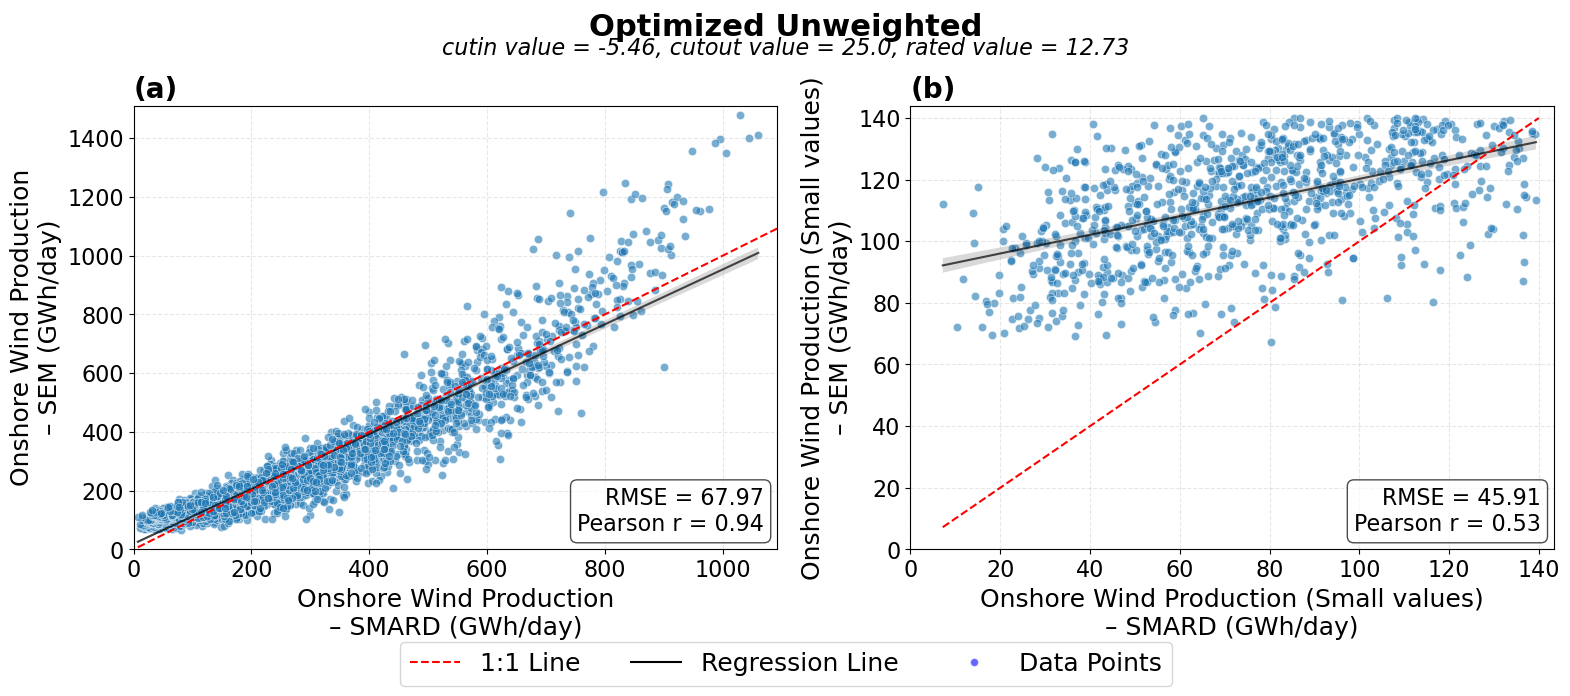

In [125]:
plot_onshore(df_unweighted, "Optimized Unweighted", params=[result_onshore.x[0], result_onshore.x[1], result_onshore.x[2]])

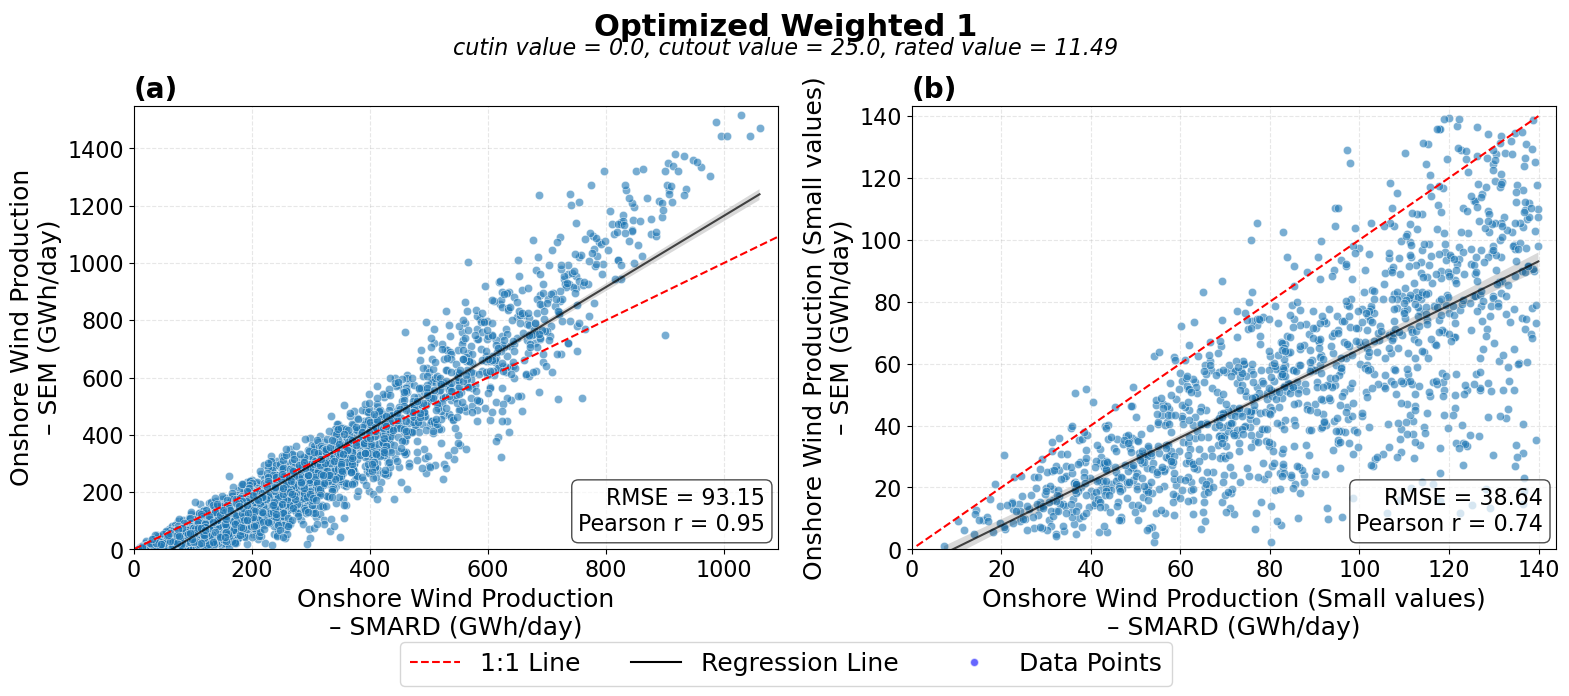

In [126]:
plot_onshore(df_weighted_1, "Optimized Weighted 1", params=[result_onshore_weighted_1.x[0], result_onshore_weighted_1.x[1], result_onshore_weighted_1.x[2]])

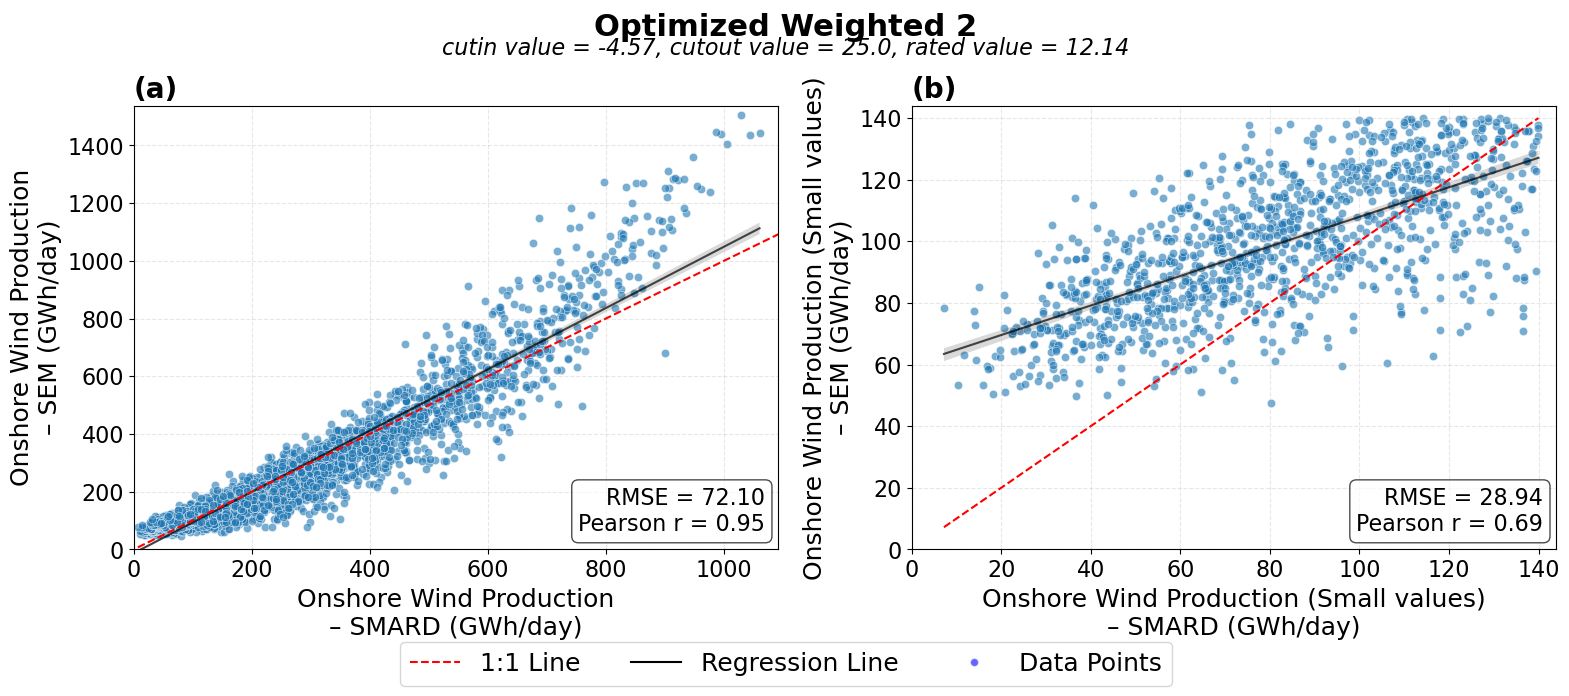

In [127]:
plot_onshore(df_weighted_2, "Optimized Weighted 2", params=[result_onshore_weighted_2.x[0], result_onshore_weighted_2.x[1], result_onshore_weighted_2.x[2]])

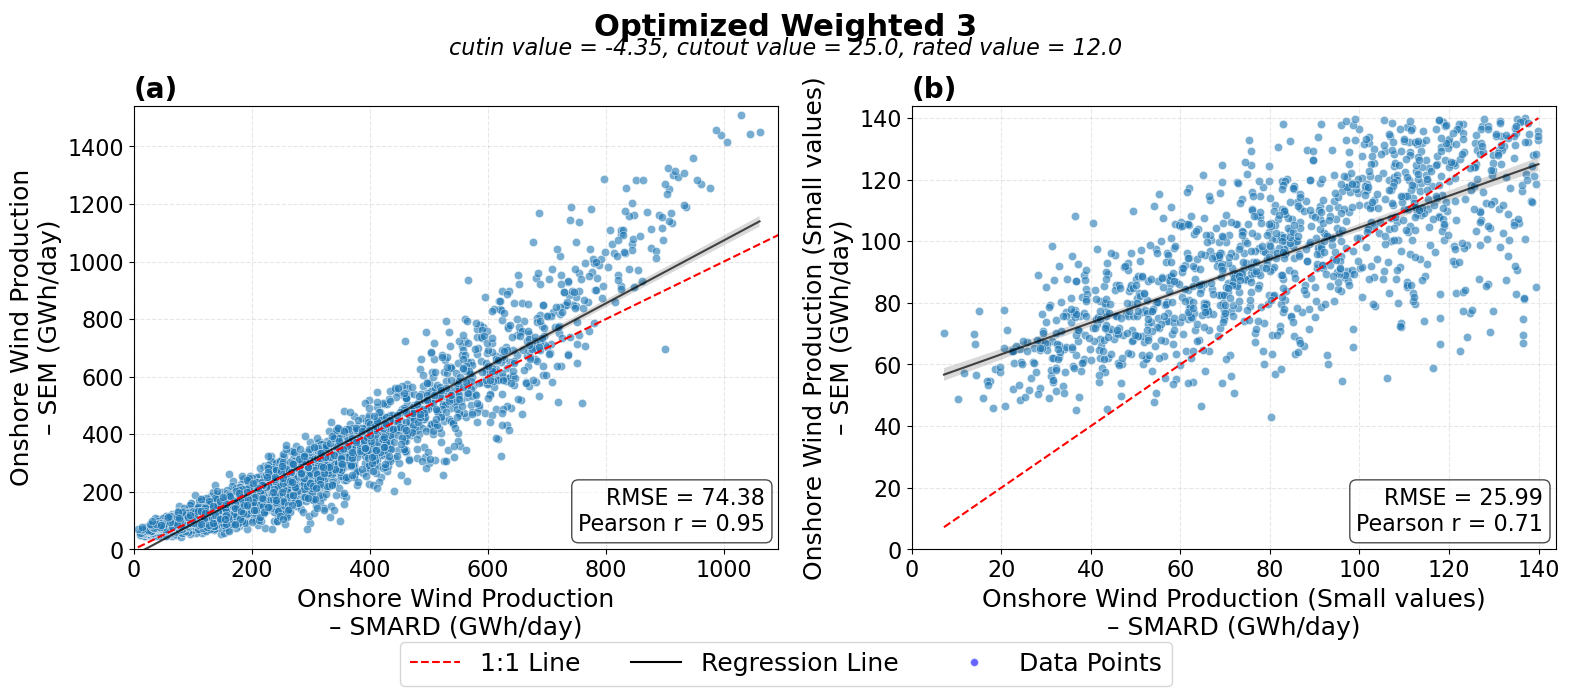

In [132]:
plot_onshore(df_weighted_3, "Optimized Weighted 3", params=[result_onshore_weighted_3.x[0], result_onshore_weighted_3.x[1], result_onshore_weighted_3.x[2]])

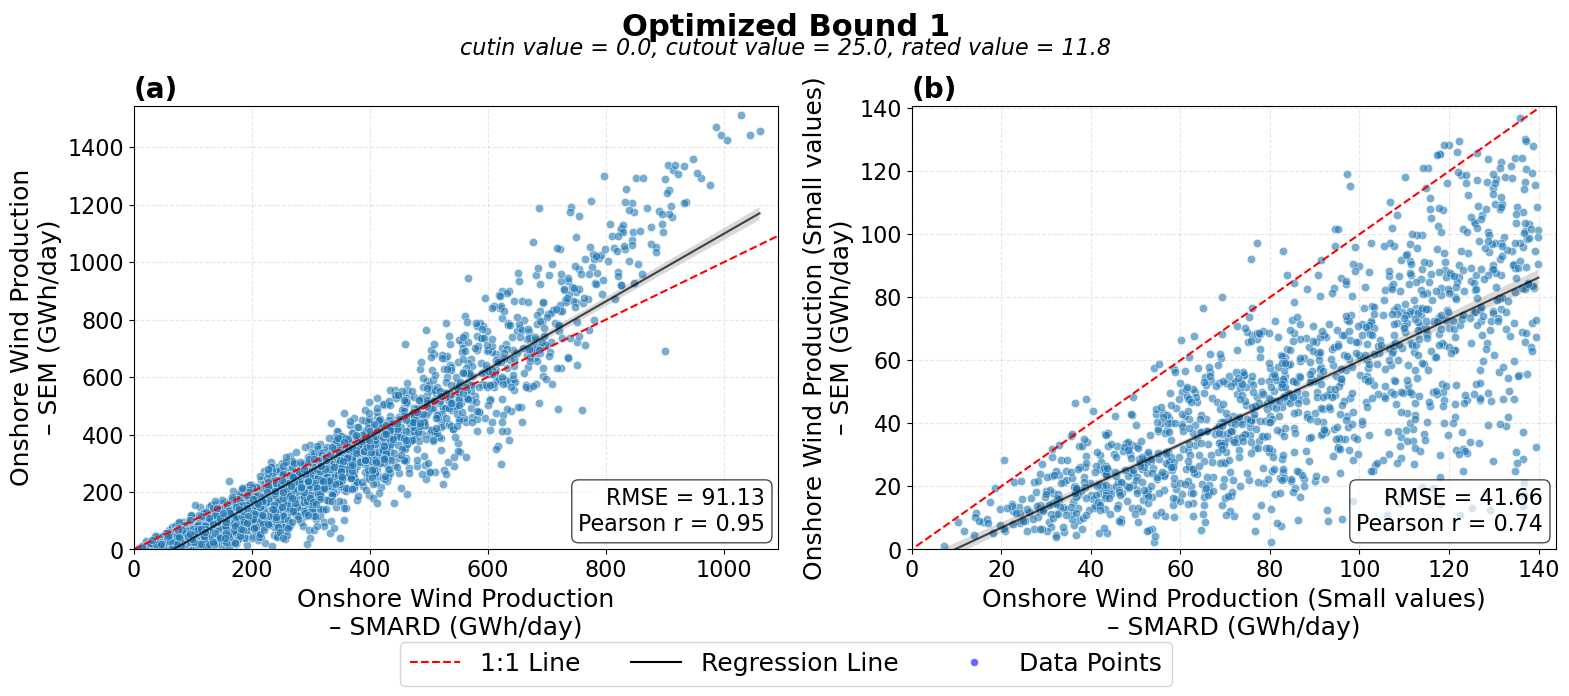

In [129]:
plot_onshore(df_bound_1, "Optimized Bound 1", params=[result_onshore_bound_1.x[0], result_onshore_bound_1.x[1], result_onshore_bound_1.x[2]])

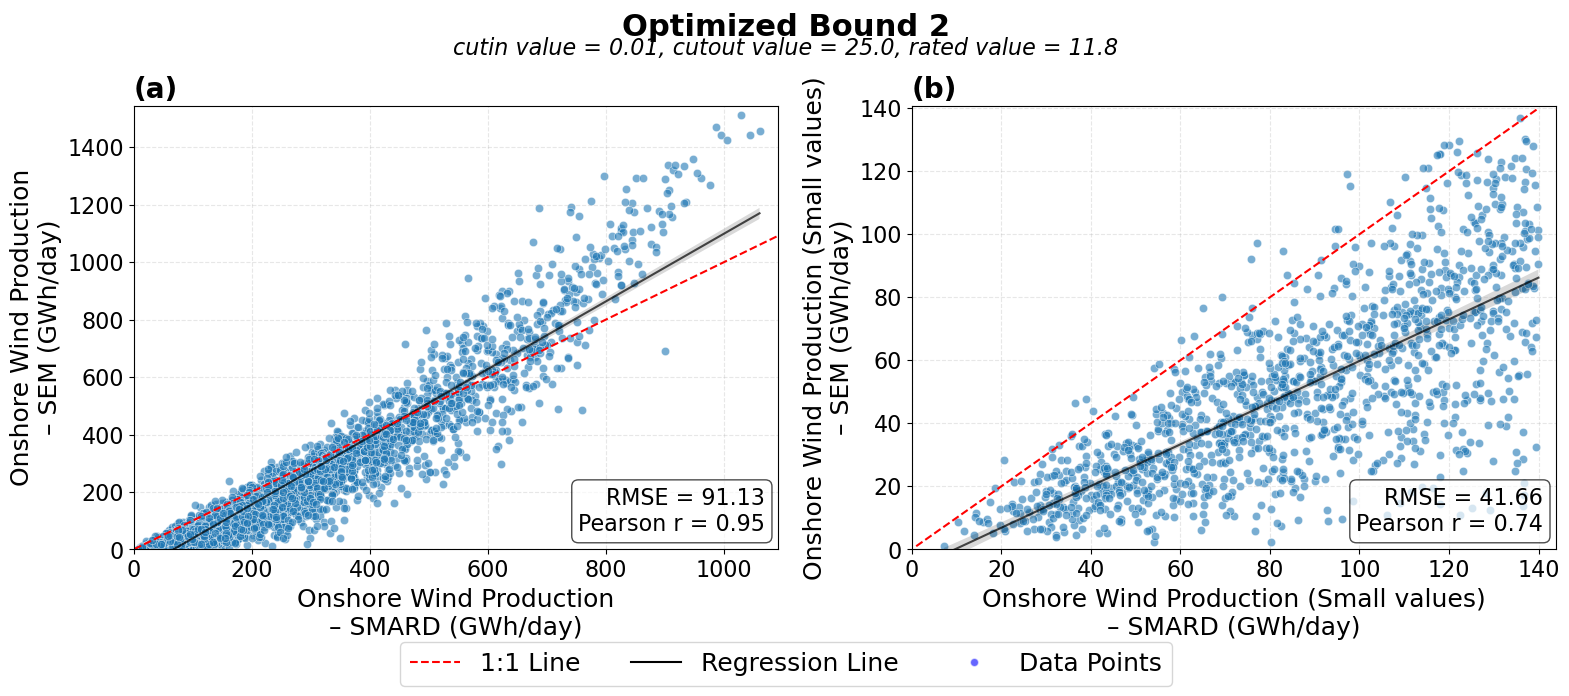

In [130]:
plot_onshore(df_bound_2, "Optimized Bound 2", params=[result_onshore_bound_2.x[0], result_onshore_bound_2.x[1], result_onshore_bound_2.x[2]])